# DSAI 4103 — Business Analytics Project
## Notebook 01: Exploratory Data Analysis (EDA)
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Objective:** Understand the dataset structure, handle missing values, and generate visualizations for the Power BI dashboard.

---
## 0. Install & Import Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE = '/content/drive/MyDrive/Course_Project/'

import os
os.makedirs(BASE + 'data/processed', exist_ok=True)
os.makedirs(BASE + 'outputs/figures', exist_ok=True)

print(os.listdir(BASE + 'data/raw/'))
# Should print the 3 file names ✅

['diabetic_data.csv', 'IDs_mapping.csv', 'Hospital_General_Information.csv']


In [4]:
# !pip install pandas numpy matplotlib seaborn missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import warnings
import os

warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Output directory for Power BI exports
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load All Three Data Files

In [5]:
# File 1: Main patient encounters
df   = pd.read_csv(BASE + 'data/raw/diabetic_data.csv')

# File 2: ID mappings (admission type, discharge disposition, admission source)
ids  = pd.read_csv(BASE + 'data/raw/IDs_mapping.csv')

# File 3: CMS Hospital General Information
hosp = pd.read_csv(BASE + 'data/raw/Hospital_General_Information.csv')

print(f'diabetic_data      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'IDs_mapping        : {ids.shape[0]:,} rows × {ids.shape[1]} columns')
print(f'Hospital_Info      : {hosp.shape[0]:,} rows × {hosp.shape[1]} columns')

diabetic_data      : 101,766 rows × 50 columns
IDs_mapping        : 62 rows × 3 columns
Hospital_Info      : 5,426 rows × 38 columns


In [6]:
# Preview main dataset
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Preview ID mappings
ids.head(10)

,mapping_type,id,description
0,admission_type_id,1,Emergency
1,admission_type_id,2,Urgent
2,admission_type_id,3,Elective
3,admission_type_id,4,Newborn
4,admission_type_id,5,Not Available
5,admission_type_id,6,NaN
6,admission_type_id,7,Trauma Center
7,admission_type_id,8,Not Mapped
8,discharge_disposition_id,1,Discharged to home
9,discharge_disposition_id,2,Discharged/transferred to another short term h...


In [8]:
# Preview hospital metadata
hosp.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


---
## 2. Dataset Structure

In [9]:
# Shape
print('=' * 50)
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print('=' * 50)

Rows    : 101,766
Columns : 50


In [10]:
# Data types
print('Column Data Types:')
print('-' * 40)
print(df.dtypes.to_string())

Column Data Types:
----------------------------------------
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 ob

In [11]:
# Column-level info
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

---
## 3. Handle '?' Values (True Missing Data)

In [12]:
# The dataset uses '?' to represent missing values — replace with NaN
df.replace('?', np.nan, inplace=True)

print("Replaced all '?' with NaN.")
print(f"Total missing cells: {df.isnull().sum().sum():,}")

Replaced all '?' with NaN.
Total missing cells: 374,017


In [13]:
# Missing value analysis — count and percentage per column
missing = pd.DataFrame({
    'missing_count'  : df.isnull().sum(),
    'missing_pct'    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
print(missing.to_string())

Columns with missing values:
                   missing_count  missing_pct
weight                     98569        96.86
max_glu_serum              96420        94.75
A1Cresult                  84748        83.28
medical_specialty          49949        49.08
payer_code                 40256        39.56
race                        2273         2.23
diag_3                      1423         1.40
diag_2                       358         0.35
diag_1                        21         0.02


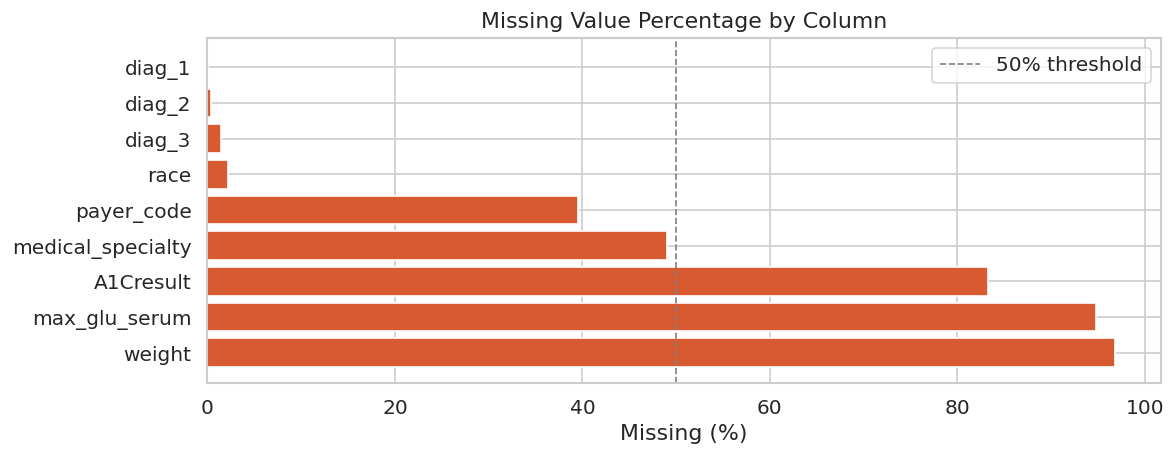

Saved: outputs/figures/00_missing_values.png


In [14]:
# Visualise missing value pattern
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing.index.tolist()
ax.barh(cols_with_missing, missing['missing_pct'], color='#D85A30')
ax.axvline(50, color='gray', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Percentage by Column')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/00_missing_values.png')
plt.show()
print('Saved: outputs/figures/00_missing_values.png')

In [15]:
# Drop high-missing columns (>50% missing) — weight, payer_code
cols_to_drop = missing[missing['missing_pct'] > 50].index.tolist()
print(f'Dropping columns with >50% missing: {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)

# Keep medical_specialty but fill NaN with 'Missing'
if 'medical_specialty' in df.columns:
    df['medical_specialty'].fillna('Missing', inplace=True)
    print("Filled 'medical_specialty' NaN with 'Missing'")

# Fill race NaN with 'Unknown'
if 'race' in df.columns:
    df['race'].fillna('Unknown', inplace=True)
    print("Filled 'race' NaN with 'Unknown'")

print(f'\nDataset shape after cleaning: {df.shape}')

Dropping columns with >50% missing: ['weight', 'max_glu_serum', 'A1Cresult']
Filled 'medical_specialty' NaN with 'Missing'
Filled 'race' NaN with 'Unknown'

Dataset shape after cleaning: (101766, 47)


---
## 4. Basic Statistical Summary

In [16]:
# Numeric columns summary
print('Numeric Columns — Descriptive Statistics:')
df.describe().T.round(2)

Numeric Columns — Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.400000e+00,2.990000e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.310000e+01,1.967000e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.340000e+00,1.710000e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602000e+01,8.130000e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.700000e-01,1.270000e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [17]:
# Categorical columns summary
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')

for col in ['race', 'gender', 'age', 'readmitted', 'A1Cresult', 'change', 'diabetesMed']:
    if col in df.columns:
        print(f'--- {col} ---')
        print(df[col].value_counts(dropna=False))
        print()

Categorical columns (34): ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

--- race ---
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     27

In [18]:
# Unique patient vs encounter count
print(f"Total encounters  : {df.shape[0]:,}")
print(f"Unique patients   : {df['patient_nbr'].nunique():,}")
print(f"Unique hospitals  : {df['hospital_id' if 'hospital_id' in df.columns else 'encounter_id'].nunique():,}")
print(f"Duplicate patients: {df.shape[0] - df['patient_nbr'].nunique():,}")

Total encounters  : 101,766
Unique patients   : 71,518
Unique hospitals  : 101,766
Duplicate patients: 30,248


---
## 5. Merge ID Mappings (File 2)

In [19]:
# Split IDs_mapping into three lookup dictionaries
admission_type_map = (
    ids[ids['mapping_type'] == 'admission_type_id']
    .set_index('id')['description']
    .to_dict()
)
discharge_map = (
    ids[ids['mapping_type'] == 'discharge_disposition_id']
    .set_index('id')['description']
    .to_dict()
)
admission_source_map = (
    ids[ids['mapping_type'] == 'admission_source_id']
    .set_index('id')['description']
    .to_dict()
)

# Apply mappings to create human-readable columns
df['admission_type_desc']      = df['admission_type_id'].map(admission_type_map)
df['discharge_disposition_desc'] = df['discharge_disposition_id'].map(discharge_map)
df['admission_source_desc']    = df['admission_source_id'].map(admission_source_map)

print('ID mappings applied successfully.')
print(df[['admission_type_id','admission_type_desc']].drop_duplicates().sort_values('admission_type_id'))

ID mappings applied successfully.
       admission_type_id admission_type_desc
1                      1           Emergency
5                      2              Urgent
6                      3            Elective
2043                   4             Newborn
3089                   5       Not Available
0                      6                 NaN
45829                  7       Trauma Center
7789                   8          Not Mapped


---
## 6. Recode Target Variable

In [20]:
# Original: '<30', '>30', 'No'
# Binary target: 1 = readmitted within 30 days, 0 = otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

counts = df['readmitted'].value_counts()
binary_counts = df['readmitted_binary'].value_counts()

print('Original readmission categories:')
print(counts)
print(f'\nBinary target distribution:')
print(binary_counts)
print(f'\nClass imbalance ratio: {binary_counts[0]/binary_counts[1]:.1f}:1 (not readmitted : readmitted <30d)')

Original readmission categories:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Class imbalance ratio: 8.0:1 (not readmitted : readmitted <30d)


---
## 7. EDA Visualisations (Power BI Ready)

All aggregated DataFrames are saved to `data/processed/` for direct import into Power BI.

### 7.1 Class Imbalance

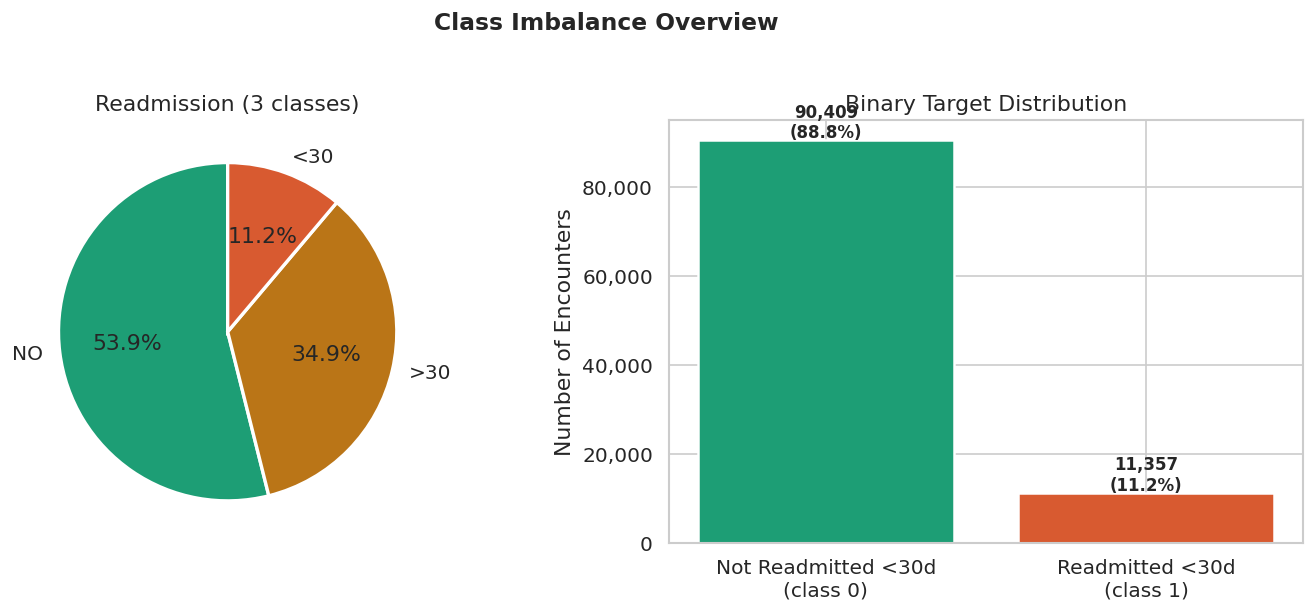

Saved: data/processed/pbi_01_readmission_distribution.csv


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original 3-class
labels_3 = counts.index.tolist()
colors_3 = ['#1D9E75', '#BA7517', '#D85A30']
axes[0].pie(counts.values, labels=labels_3, autopct='%1.1f%%',
            colors=colors_3, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Readmission (3 classes)')

# Right: binary target
bar_colors = ['#1D9E75', '#D85A30']
axes[1].bar(['Not Readmitted <30d\n(class 0)', 'Readmitted <30d\n(class 1)'],
            binary_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Binary Target Distribution')
axes[1].set_ylabel('Number of Encounters')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/01_class_imbalance.png')
plt.show()

# Save for Power BI
readmit_dist = df['readmitted'].value_counts().reset_index()
readmit_dist.columns = ['readmitted', 'count']
readmit_dist['percentage'] = (readmit_dist['count'] / len(df) * 100).round(2)
readmit_dist.to_csv('data/processed/pbi_01_readmission_distribution.csv', index=False)
print('Saved: data/processed/pbi_01_readmission_distribution.csv')

In [22]:
# RE-SAVE 01
plt.figure(figsize=(12, 5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_3 = counts.index.tolist()
colors_3 = ['#1D9E75', '#BA7517', '#D85A30']
axes[0].pie(counts.values, labels=labels_3, autopct='%1.1f%%',
            colors=colors_3, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Readmission (3 classes)')
axes[1].bar(['Not Readmitted <30d\n(class 0)', 'Readmitted <30d\n(class 1)'],
            binary_counts.values, color=['#1D9E75', '#D85A30'], edgecolor='white')
axes[1].set_title('Binary Target Distribution')
axes[1].set_ylabel('Number of Encounters')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/01_class_imbalance.png')
plt.close()
print('Saved 01_class_imbalance.png')

Saved 01_class_imbalance.png


<Figure size 1440x600 with 0 Axes>

### 7.2 Readmission Rate by Age Group

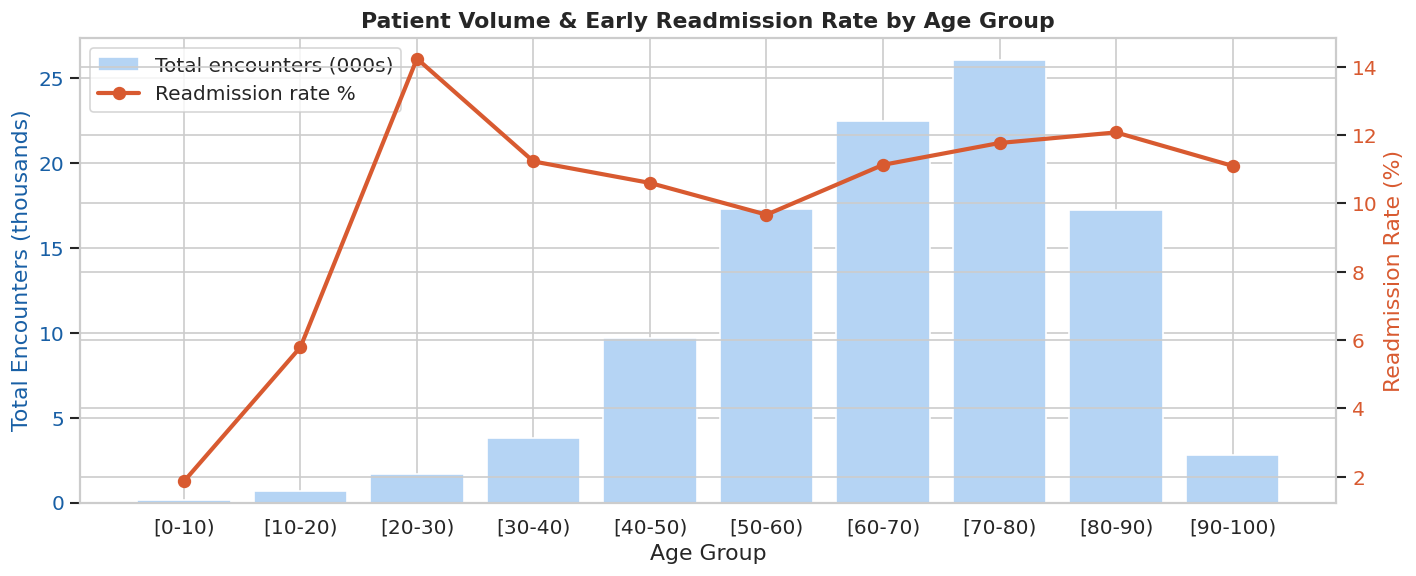

Saved: data/processed/pbi_02_age_readmission.csv


In [23]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_stats = df.groupby('age').agg(
    total=('readmitted_binary', 'count'),
    readmitted_30=('readmitted_binary', 'sum')
).reindex(age_order)
age_stats['readmission_rate'] = (age_stats['readmitted_30'] / age_stats['total'] * 100).round(2)
age_stats = age_stats.reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(age_stats['age'], age_stats['total'] / 1000,
               color='#B5D4F4', edgecolor='white', label='Total encounters (000s)')
ax1.set_ylabel('Total Encounters (thousands)', color='#185FA5')
ax1.tick_params(axis='y', labelcolor='#185FA5')

ax2 = ax1.twinx()
ax2.plot(age_stats['age'], age_stats['readmission_rate'],
         color='#D85A30', marker='o', linewidth=2.5, markersize=7, label='Readmission rate %')
ax2.set_ylabel('Readmission Rate (%)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

ax1.set_xlabel('Age Group')
ax1.set_title('Patient Volume & Early Readmission Rate by Age Group', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('outputs/figures/02_age_readmission.png')
plt.show()

# Save for Power BI
age_stats.to_csv('data/processed/pbi_02_age_readmission.csv', index=False)
print('Saved: data/processed/pbi_02_age_readmission.csv')

In [24]:
# RE-SAVE 02
fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(age_stats['age'], age_stats['total'] / 1000,
               color='#B5D4F4', edgecolor='white', label='Total encounters (000s)')
ax1.set_ylabel('Total Encounters (thousands)', color='#185FA5')
ax1.tick_params(axis='y', labelcolor='#185FA5')
ax2 = ax1.twinx()
ax2.plot(age_stats['age'], age_stats['readmission_rate'],
         color='#D85A30', marker='o', linewidth=2.5, markersize=7, label='Readmission rate %')
ax2.set_ylabel('Readmission Rate (%)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xlabel('Age Group')
ax1.set_title('Patient Volume & Early Readmission Rate by Age Group', fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/02_age_readmission.png')
plt.close()
print('Saved 02_age_readmission.png')

Saved 02_age_readmission.png


### 7.3 Readmission Rate by Race (Bias Preview)

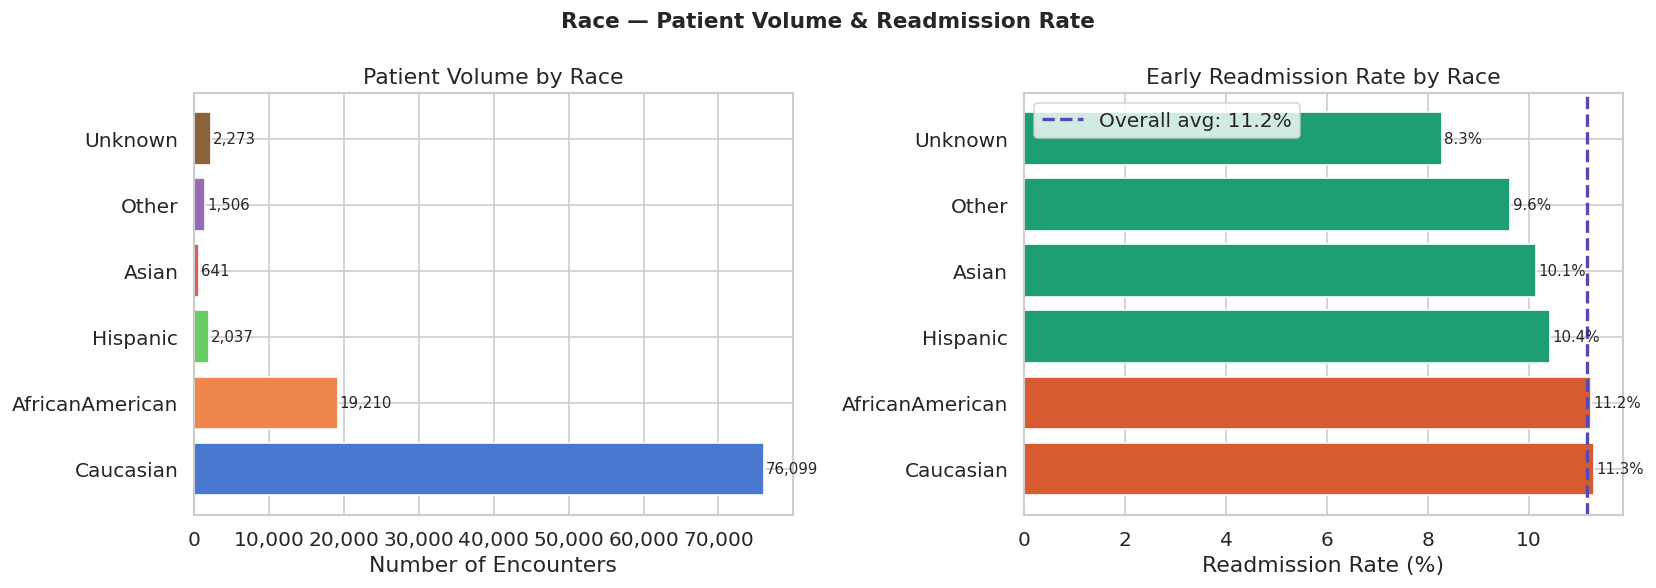

Saved: data/processed/pbi_03_race_readmission.csv


In [25]:
race_stats = df.groupby('race').agg(
    total=('readmitted_binary', 'count'),
    readmitted_30=('readmitted_binary', 'sum')
).reset_index()
race_stats['readmission_rate'] = (race_stats['readmitted_30'] / race_stats['total'] * 100).round(2)
race_stats = race_stats.sort_values('readmission_rate', ascending=False)

overall_rate = df['readmitted_binary'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: volume by race
palette = sns.color_palette('muted', len(race_stats))
axes[0].barh(race_stats['race'], race_stats['total'],
             color=palette, edgecolor='white')
axes[0].set_xlabel('Number of Encounters')
axes[0].set_title('Patient Volume by Race')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(race_stats['total']):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

# Right: readmission rate by race with benchmark
bar_colors = ['#D85A30' if r > overall_rate else '#1D9E75' for r in race_stats['readmission_rate']]
axes[1].barh(race_stats['race'], race_stats['readmission_rate'],
             color=bar_colors, edgecolor='white')
axes[1].axvline(overall_rate, color='#534AB7', linestyle='--',
                linewidth=2, label=f'Overall avg: {overall_rate:.1f}%')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].set_title('Early Readmission Rate by Race')
axes[1].legend()
for i, v in enumerate(race_stats['readmission_rate']):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Race — Patient Volume & Readmission Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_race_readmission.png')
plt.show()

race_stats.to_csv('data/processed/pbi_03_race_readmission.csv', index=False)
print('Saved: data/processed/pbi_03_race_readmission.csv')

In [26]:
# RE-SAVE 03
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('muted', len(race_stats))
axes[0].barh(race_stats['race'], race_stats['total'], color=palette, edgecolor='white')
axes[0].set_xlabel('Number of Encounters')
axes[0].set_title('Patient Volume by Race')
bar_colors = ['#D85A30' if r > overall_rate else '#1D9E75' for r in race_stats['readmission_rate']]
axes[1].barh(race_stats['race'], race_stats['readmission_rate'], color=bar_colors, edgecolor='white')
axes[1].axvline(overall_rate, color='#534AB7', linestyle='--', linewidth=2,
                label=f'Overall avg: {overall_rate:.1f}%')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].set_title('Early Readmission Rate by Race')
axes[1].legend()
plt.suptitle('Race — Patient Volume & Readmission Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/03_race_readmission.png')
plt.close()
print('Saved 03_race_readmission.png')

Saved 03_race_readmission.png


### 7.4 Time in Hospital Distribution

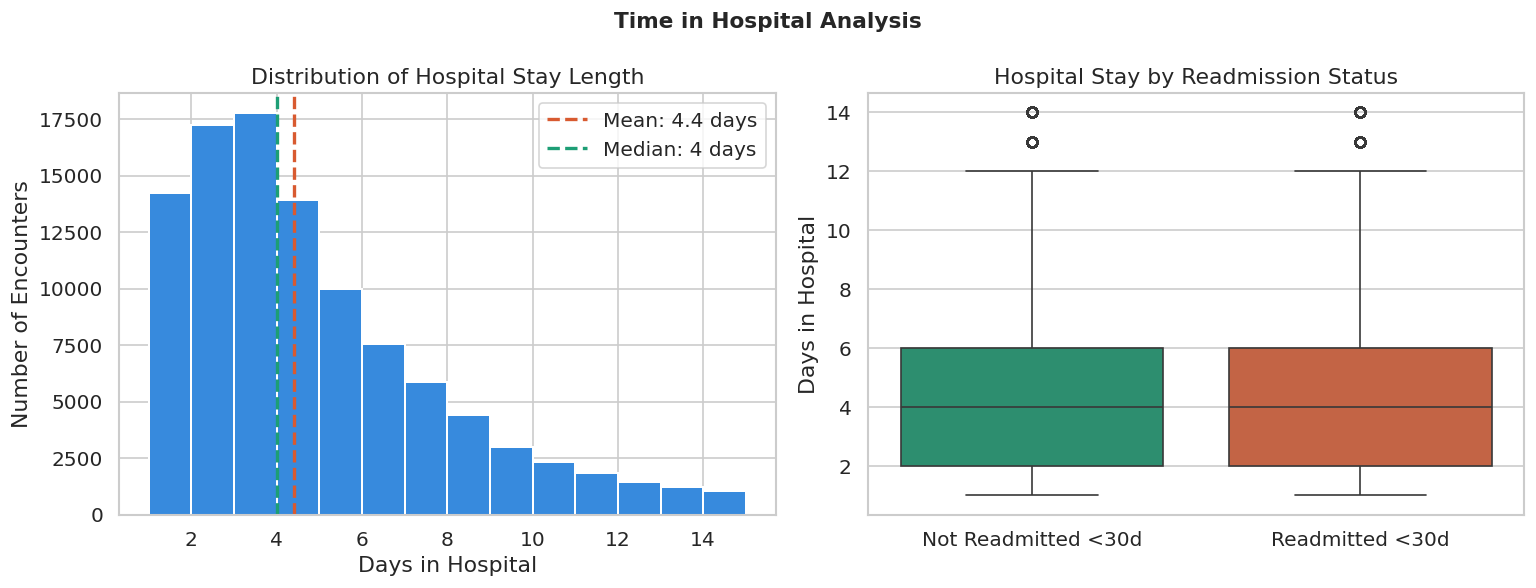

Saved: data/processed/pbi_04_time_in_hospital.csv


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram
axes[0].hist(df['time_in_hospital'], bins=14, range=(1, 15),
             color='#378ADD', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['time_in_hospital'].mean(), color='#D85A30',
                linestyle='--', linewidth=2,
                label=f'Mean: {df["time_in_hospital"].mean():.1f} days')
axes[0].axvline(df['time_in_hospital'].median(), color='#1D9E75',
                linestyle='--', linewidth=2,
                label=f'Median: {df["time_in_hospital"].median():.0f} days')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('Number of Encounters')
axes[0].set_title('Distribution of Hospital Stay Length')
axes[0].legend()

# Right: box plot by readmission
readmit_labels = {0: 'Not Readmitted <30d', 1: 'Readmitted <30d'}
df['readmit_label'] = df['readmitted_binary'].map(readmit_labels)
sns.boxplot(data=df, x='readmit_label', y='time_in_hospital',
            palette=['#1D9E75', '#D85A30'], ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Days in Hospital')
axes[1].set_title('Hospital Stay by Readmission Status')

plt.suptitle('Time in Hospital Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/04_time_in_hospital.png')
plt.show()

tih = df.groupby('time_in_hospital').agg(
    count=('readmitted_binary', 'count'),
    readmission_rate=('readmitted_binary', 'mean')
).reset_index()
tih['readmission_rate'] = (tih['readmission_rate'] * 100).round(2)
tih.to_csv('data/processed/pbi_04_time_in_hospital.csv', index=False)
print('Saved: data/processed/pbi_04_time_in_hospital.csv')

In [28]:
# RE-SAVE 04
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['time_in_hospital'], bins=14, range=(1, 15),
             color='#378ADD', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['time_in_hospital'].mean(), color='#D85A30', linestyle='--',
                linewidth=2, label=f'Mean: {df["time_in_hospital"].mean():.1f} days')
axes[0].axvline(df['time_in_hospital'].median(), color='#1D9E75', linestyle='--',
                linewidth=2, label=f'Median: {df["time_in_hospital"].median():.0f} days')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('Number of Encounters')
axes[0].set_title('Distribution of Hospital Stay Length')
axes[0].legend()
sns.boxplot(data=df, x='readmit_label', y='time_in_hospital',
            palette=['#1D9E75', '#D85A30'], ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Days in Hospital')
axes[1].set_title('Hospital Stay by Readmission Status')
plt.suptitle('Time in Hospital Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/04_time_in_hospital.png')
plt.close()
print('Saved 04_time_in_hospital.png')

Saved 04_time_in_hospital.png


### 7.5 Number of Medications vs Readmission

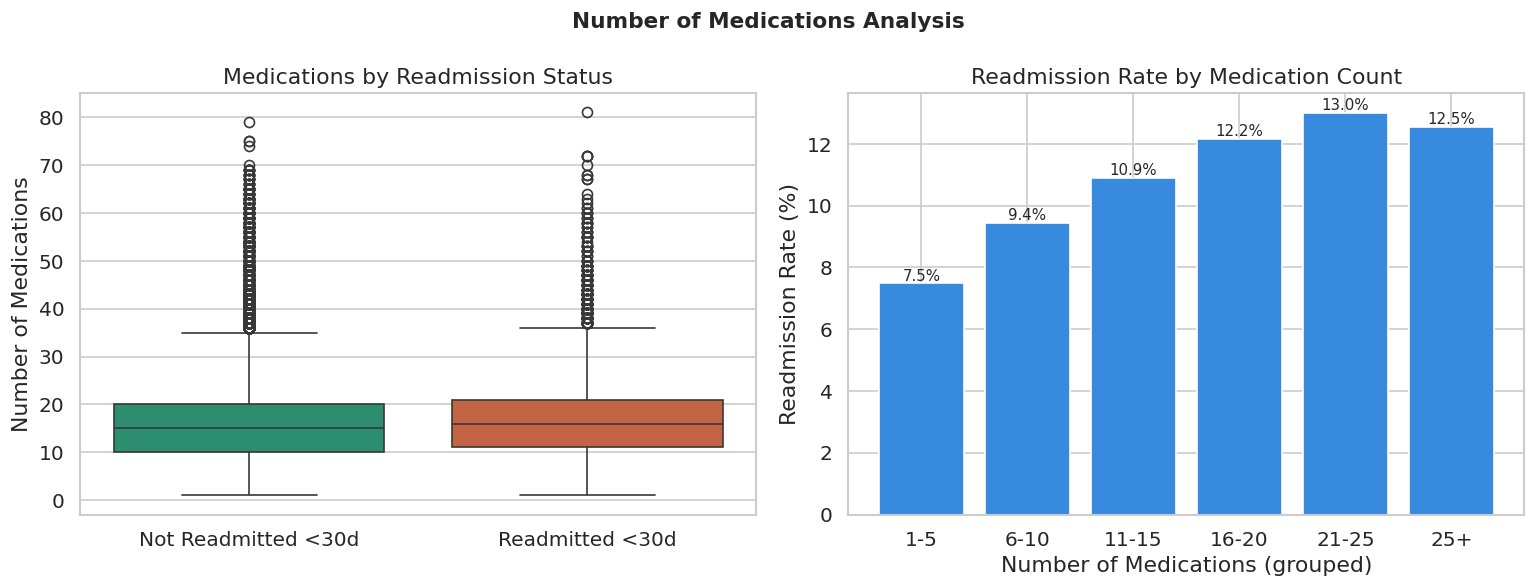

Saved: data/processed/pbi_05_medications.csv


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plot
sns.boxplot(data=df, x='readmit_label', y='num_medications',
            palette=['#1D9E75', '#D85A30'], ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Medications')
axes[0].set_title('Medications by Readmission Status')

# Right: readmission rate by medication count (binned)
df['med_bin'] = pd.cut(df['num_medications'],
                        bins=[0, 5, 10, 15, 20, 25, 100],
                        labels=['1-5', '6-10', '11-15', '16-20', '21-25', '25+'])
med_stats = df.groupby('med_bin')['readmitted_binary'].mean().reset_index()
med_stats['readmission_rate'] = (med_stats['readmitted_binary'] * 100).round(2)

axes[1].bar(med_stats['med_bin'].astype(str), med_stats['readmission_rate'],
            color='#378ADD', edgecolor='white')
axes[1].set_xlabel('Number of Medications (grouped)')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Medication Count')
for i, v in enumerate(med_stats['readmission_rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Number of Medications Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_medications.png')
plt.show()

med_export = df.groupby('med_bin').agg(
    count=('readmitted_binary', 'count'),
    readmission_rate=('readmitted_binary', 'mean')
).reset_index()
med_export['readmission_rate'] = (med_export['readmission_rate'] * 100).round(2)
med_export['med_bin'] = med_export['med_bin'].astype(str)
med_export.to_csv('data/processed/pbi_05_medications.csv', index=False)
print('Saved: data/processed/pbi_05_medications.csv')

In [30]:
# RE-SAVE 05
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x='readmit_label', y='num_medications',
            palette=['#1D9E75', '#D85A30'], ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Medications')
axes[0].set_title('Medications by Readmission Status')
axes[1].bar(med_stats['med_bin'].astype(str), med_stats['readmission_rate'],
            color='#378ADD', edgecolor='white')
axes[1].set_xlabel('Number of Medications (grouped)')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Medication Count')
plt.suptitle('Number of Medications Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/05_medications.png')
plt.close()
print('Saved 05_medications.png')

Saved 05_medications.png


### 7.6 HbA1c Test Result vs Readmission

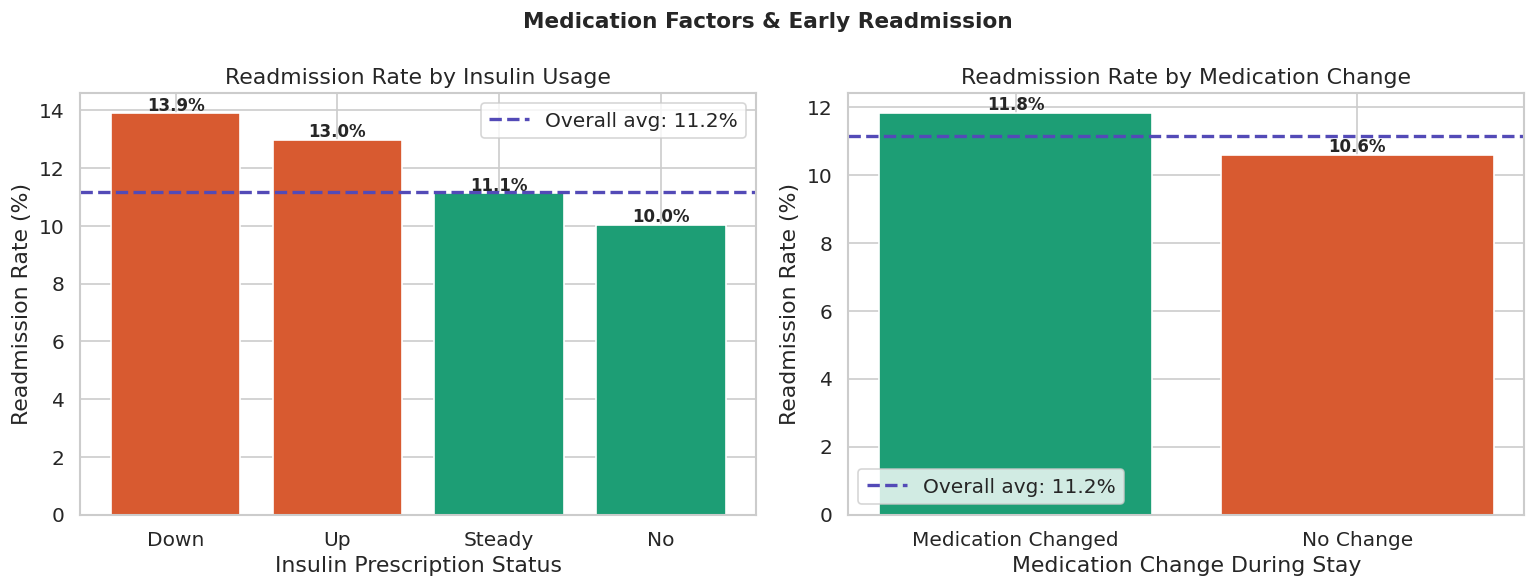

Saved successfully!


In [31]:
# A1Cresult not in this dataset version — replaced with insulin usage vs readmission

insulin_stats = df.groupby('insulin').agg(
    total=('readmitted_binary', 'count'),
    readmitted_30=('readmitted_binary', 'sum')
).reset_index()
insulin_stats['readmission_rate'] = (insulin_stats['readmitted_30'] / insulin_stats['total'] * 100).round(2)
insulin_stats = insulin_stats.sort_values('readmission_rate', ascending=False)

change_stats = df.groupby('change').agg(
    total=('readmitted_binary', 'count'),
    readmitted_30=('readmitted_binary', 'sum')
).reset_index()
change_stats['readmission_rate'] = (change_stats['readmitted_30'] / change_stats['total'] * 100).round(2)
change_stats['change'] = change_stats['change'].map({'Ch': 'Medication Changed', 'No': 'No Change'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: insulin usage vs readmission rate
bar_colors = ['#D85A30' if r > overall_rate else '#1D9E75'
              for r in insulin_stats['readmission_rate']]
axes[0].bar(insulin_stats['insulin'], insulin_stats['readmission_rate'],
            color=bar_colors, edgecolor='white')
axes[0].axhline(overall_rate, color='#534AB7', linestyle='--',
                linewidth=2, label=f'Overall avg: {overall_rate:.1f}%')
axes[0].set_xlabel('Insulin Prescription Status')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Insulin Usage')
axes[0].legend()
for i, v in enumerate(insulin_stats['readmission_rate']):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Right: medication change vs readmission rate
axes[1].bar(change_stats['change'], change_stats['readmission_rate'],
            color=['#1D9E75', '#D85A30'], edgecolor='white')
axes[1].axhline(overall_rate, color='#534AB7', linestyle='--',
                linewidth=2, label=f'Overall avg: {overall_rate:.1f}%')
axes[1].set_xlabel('Medication Change During Stay')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Medication Change')
axes[1].legend()
for i, v in enumerate(change_stats['readmission_rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Medication Factors & Early Readmission', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/06_medication_factors.png')
plt.show()

# Save for Power BI
insulin_stats.to_csv(BASE + 'data/processed/pbi_06_insulin_readmission.csv', index=False)
change_stats.to_csv(BASE + 'data/processed/pbi_06_change_readmission.csv', index=False)
print('Saved successfully!')

### 7.7 Top 10 Primary Diagnoses

diag1_group
Circulatory               30437
Respiratory               14423
Digestive                  9475
Diabetes                   8757
Injury & Poisoning         6974
Other                      6202
Genitourinary              5117
Musculoskeletal            4957
Neoplasms                  3433
Infectious & Parasitic     2768
Endocrine/Metabolic        2702
Skin Diseases              2614
Mental Disorders           2262
External/Supplemental      1645
Name: count, dtype: int64


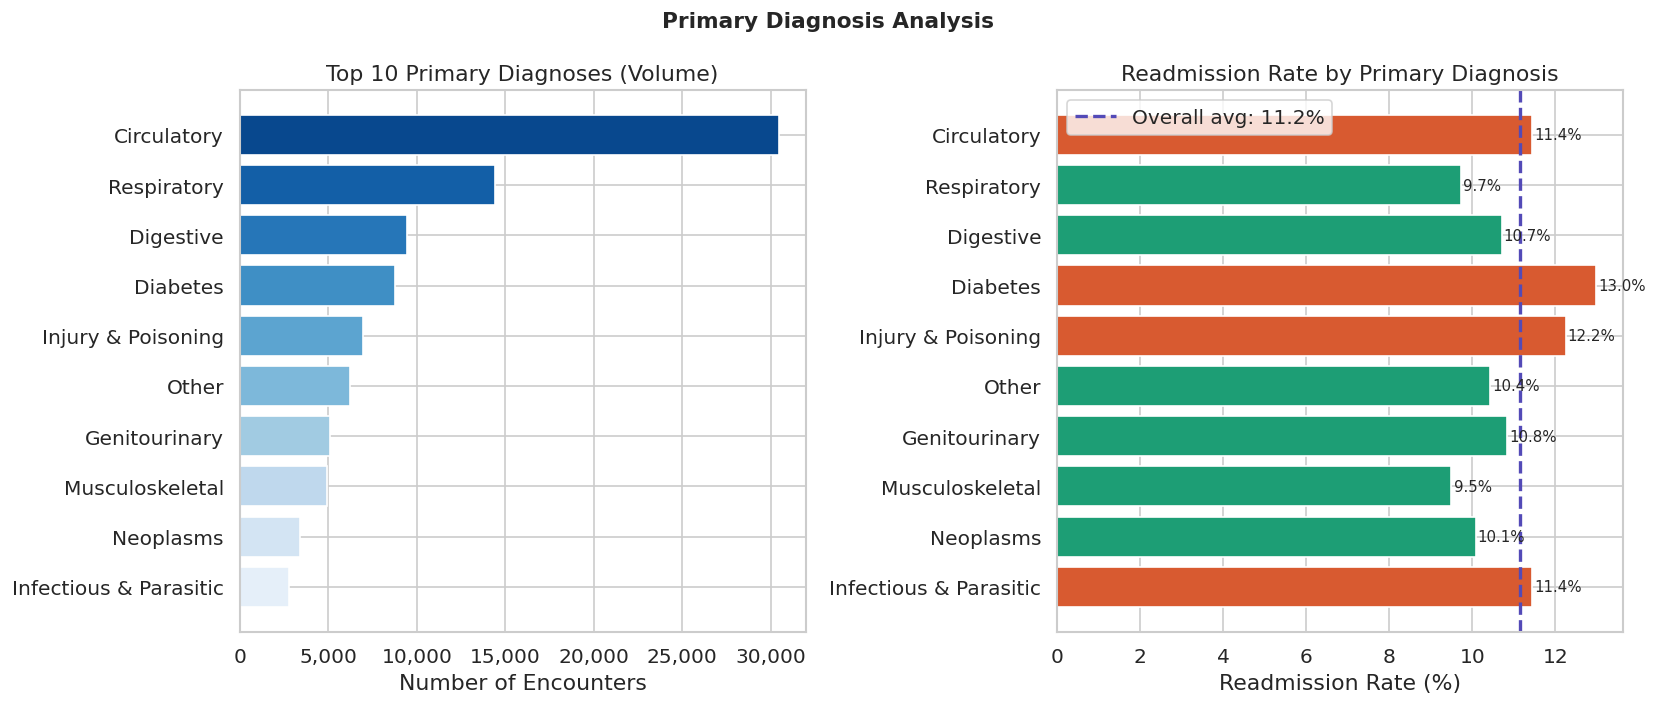

Saved: data/processed/pbi_07_diagnoses.csv


In [32]:
# Map ICD-9 codes to diagnosis group names (from paper Table 2)
def map_diag(code):
    try:
        c = str(code).strip()
        if c.startswith('250'):                    return 'Diabetes'
        if c.startswith('E') or c.startswith('V'): return 'External/Supplemental'
        n = float(c)
        if 390 <= n <= 459 or n == 785:            return 'Circulatory'
        if 460 <= n <= 519 or n == 786:            return 'Respiratory'
        if 520 <= n <= 579 or n == 787:            return 'Digestive'
        if 800 <= n <= 999:                        return 'Injury & Poisoning'
        if 710 <= n <= 739:                        return 'Musculoskeletal'
        if 580 <= n <= 629 or n == 788:            return 'Genitourinary'
        if 140 <= n <= 239:                        return 'Neoplasms'
        if 290 <= n <= 319:                        return 'Mental Disorders'
        if 240 <= n <= 279:                        return 'Endocrine/Metabolic'
        if 680 <= n <= 709 or n == 782:            return 'Skin Diseases'
        if 1 <= n <= 139:                          return 'Infectious & Parasitic'  # ← fixed
        return 'Other'
    except:
        return 'Other'

df['diag1_group'] = df['diag_1'].apply(map_diag)
print(df['diag1_group'].value_counts())

df['diag1_group'] = df['diag_1'].apply(map_diag)

diag_stats = df.groupby('diag1_group').agg(
    count=('readmitted_binary', 'count'),
    readmission_rate=('readmitted_binary', 'mean')
).reset_index()
diag_stats['readmission_rate'] = (diag_stats['readmission_rate'] * 100).round(2)
diag_stats = diag_stats.sort_values('count', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: top diagnoses by volume
palette = sns.color_palette('Blues_r', len(diag_stats))
axes[0].barh(diag_stats['diag1_group'], diag_stats['count'],
             color=palette, edgecolor='white')
axes[0].set_xlabel('Number of Encounters')
axes[0].set_title('Top 10 Primary Diagnoses (Volume)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].invert_yaxis()

# Right: readmission rate per diagnosis
rate_colors = ['#D85A30' if r > overall_rate else '#1D9E75'
               for r in diag_stats['readmission_rate']]
axes[1].barh(diag_stats['diag1_group'], diag_stats['readmission_rate'],
             color=rate_colors, edgecolor='white')
axes[1].axvline(overall_rate, color='#534AB7', linestyle='--',
                linewidth=2, label=f'Overall avg: {overall_rate:.1f}%')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Primary Diagnosis')
axes[1].legend()
axes[1].invert_yaxis()
for i, v in enumerate(diag_stats['readmission_rate']):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Primary Diagnosis Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/07_diagnoses.png')
plt.show()

diag_stats.to_csv('data/processed/pbi_07_diagnoses.csv', index=False)
print('Saved: data/processed/pbi_07_diagnoses.csv')

In [33]:
# RE-SAVE 07
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = sns.color_palette('Blues_r', len(diag_stats))
axes[0].barh(diag_stats['diag1_group'], diag_stats['count'], color=palette, edgecolor='white')
axes[0].set_xlabel('Number of Encounters')
axes[0].set_title('Top 10 Primary Diagnoses (Volume)')
axes[0].invert_yaxis()
rate_colors = ['#D85A30' if r > overall_rate else '#1D9E75' for r in diag_stats['readmission_rate']]
axes[1].barh(diag_stats['diag1_group'], diag_stats['readmission_rate'],
             color=rate_colors, edgecolor='white')
axes[1].axvline(overall_rate, color='#534AB7', linestyle='--', linewidth=2,
                label=f'Overall avg: {overall_rate:.1f}%')
axes[1].set_xlabel('Readmission Rate (%)')
axes[1].set_title('Readmission Rate by Primary Diagnosis')
axes[1].legend()
axes[1].invert_yaxis()
plt.suptitle('Primary Diagnosis Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/07_diagnoses.png')
plt.close()
print('Saved 07_diagnoses.png')

Saved 07_diagnoses.png


---
## 8. Correlation Heatmap (Numeric Features)

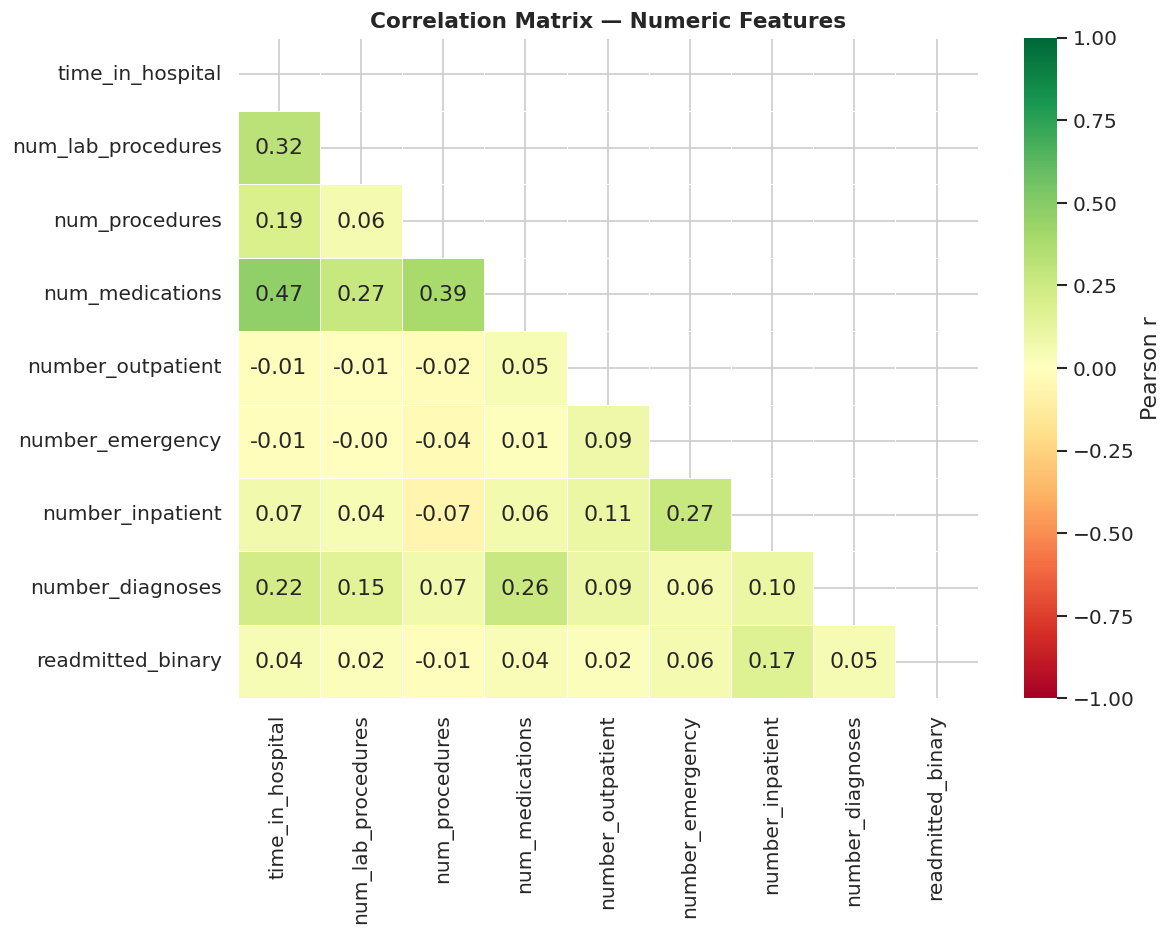

Saved: outputs/figures/08_correlation_heatmap.png


In [34]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'readmitted_binary']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/08_correlation_heatmap.png')
plt.show()
print('Saved: outputs/figures/08_correlation_heatmap.png')

In [35]:
# RE-SAVE 08
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'readmitted_binary']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/08_correlation_heatmap.png')
plt.close()
print('Saved 08_correlation_heatmap.png')

Saved 08_correlation_heatmap.png


---
## 9. Save Cleaned Dataset for Modelling

In [36]:
# Keep one encounter per patient (first encounter only)
df_unique = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()
print(f'Original encounters : {len(df):,}')
print(f'Unique patients     : {len(df_unique):,}')
print(f'Removed duplicates  : {len(df) - len(df_unique):,}')

# Remove hospice / expired patients (discharge codes 11, 13, 14, 19, 20, 21)
hospice_codes = [11, 13, 14, 19, 20, 21]
df_unique = df_unique[~df_unique['discharge_disposition_id'].isin(hospice_codes)].copy()
print(f'After removing hospice/expired: {len(df_unique):,}')

# Save cleaned dataset
df_unique.to_csv('data/processed/diabetic_cleaned.csv', index=False)
print('\nSaved: data/processed/diabetic_cleaned.csv')
print(f'Final shape: {df_unique.shape}')

Original encounters : 101,766
Unique patients     : 71,518
Removed duplicates  : 30,248
After removing hospice/expired: 69,973

Saved: data/processed/diabetic_cleaned.csv
Final shape: (69973, 54)


In [37]:
# Verify all figures saved
import os
figs = sorted(os.listdir(BASE + 'outputs/figures/'))
print(f'Total figures saved: {len(figs)}')
for f in figs:
    print(f'  ✓ {f}')

Total figures saved: 21
  ✓ 01_class_imbalance.png
  ✓ 02_age_readmission.png
  ✓ 03_race_readmission.png
  ✓ 04_time_in_hospital.png
  ✓ 05_medications.png
  ✓ 06_medication_factors.png
  ✓ 07_diagnoses.png
  ✓ 08_correlation_heatmap.png
  ✓ 09_engineered_features.png
  ✓ 10_train_test_split.png
  ✓ 11_model_evaluation.png
  ✓ 12_risk_score_dist.png
  ✓ 13_feature_importance.png
  ✓ 14_shap_summary.png
  ✓ 15_shap_bar.png
  ✓ 16_shap_waterfall.png
  ✓ 17_shap_dependence.png
  ✓ 18_bias_race.png
  ✓ 19_bias_gender.png
  ✓ 20_bias_age.png
  ✓ 21_bias_heatmap.png


---
## 10. EDA Summary

In [38]:
print('=' * 55)
print('           EDA SUMMARY')
print('=' * 55)
print(f'Total encounters loaded       : {len(df):>10,}')
print(f'Unique patients (model-ready) : {len(df_unique):>10,}')
print(f'Features after cleaning       : {df_unique.shape[1]:>10}')
print(f'Target: readmitted <30d       : {df_unique["readmitted_binary"].sum():>10,} ({df_unique["readmitted_binary"].mean()*100:.1f}%)')
print(f'Target: not readmitted <30d   : {(df_unique["readmitted_binary"]==0).sum():>10,} ({(df_unique["readmitted_binary"]==0).mean()*100:.1f}%)')
print('-' * 55)
print('Columns dropped (>50% missing):', cols_to_drop)
print('-' * 55)
print('Power BI CSVs saved to: data/processed/')
print('Figures saved to      : outputs/figures/')
print('Cleaned data saved to : data/processed/diabetic_cleaned.csv')
print('=' * 55)


           EDA SUMMARY
Total encounters loaded       :    101,766
Unique patients (model-ready) :     69,973
Features after cleaning       :         54
Target: readmitted <30d       :      6,277 (9.0%)
Target: not readmitted <30d   :     63,696 (91.0%)
-------------------------------------------------------
Columns dropped (>50% missing): ['weight', 'max_glu_serum', 'A1Cresult']
-------------------------------------------------------
Power BI CSVs saved to: data/processed/
Figures saved to      : outputs/figures/
Cleaned data saved to : data/processed/diabetic_cleaned.csv
